# 04 Q4 Efficiency

Main-body table notebook for representative cost comparisons.

In [ ]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import real_final_viz_helpers as viz
importlib.reload(viz)

PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
annotate_demo  = viz.annotate_demo
apply_style    = viz.apply_style
load_csv       = viz.load_csv
panel_label    = viz.panel_label
preview_frame  = viz.preview_frame

In [21]:
q4_eff = load_csv('q4_efficiency_table.csv')
preview_frame(q4_eff)

rows=6 cols=18
['question', 'dataset_scope', 'dataset', 'model_name', 'model', 'status', 'error', 'benchmark_epochs', 'build_sec', 'train_sec', 'infer_sec', 'total_params', 'active_params', 'timestamp_utc', 'train_time_ratio', 'infer_time_ratio', 'data_status', 'data_note']


,question,dataset_scope,dataset,model_name,model,status,error,benchmark_epochs,build_sec,train_sec,infer_sec,total_params,active_params,timestamp_utc,train_time_ratio,infer_time_ratio,data_status,data_note
0,q4,dynamic,beauty,SASRec,sasrec,demo_dummy,NaN,1,4.2,11.8,1.90,1254016,1254016,2026-04-19T00:00:00Z,1.00,1.00,demo_dummy,Preview-only synthetic values for notebook des...
1,q4,dynamic,beauty,RouteRec-dense,featured_moe_n3,demo_dummy,NaN,1,4.9,14.1,2.31,1782400,1782400,2026-04-19T00:00:00Z,1.19,1.22,demo_dummy,Preview-only synthetic values for notebook des...
2,q4,dynamic,beauty,RouteRec-sparse-final,featured_moe_n3,demo_dummy,NaN,1,5.0,13.0,2.02,1782400,1493200,2026-04-19T00:00:00Z,1.10,1.06,demo_dummy,Preview-only synthetic values for notebook des...
3,q4,stable,movielens1m,SASRec,sasrec,demo_dummy,NaN,1,7.9,19.4,3.40,1254016,1254016,2026-04-19T00:00:00Z,1.00,1.00,demo_dummy,Preview-only synthetic values for notebook des...
4,q4,stable,movielens1m,RouteRec-dense,featured_moe_n3,demo_dummy,NaN,1,8.4,23.1,4.00,1782400,1782400,2026-04-19T00:00:00Z,1.19,1.18,demo_dummy,Preview-only synthetic values for notebook des...


In [22]:
apply_style()

# ── data prep ─────────────────────────────────────────────────────────────────
table_df = q4_eff[
    ['dataset_scope', 'dataset', 'model_name',
     'total_params', 'active_params',
     'train_time_ratio', 'infer_time_ratio', 'status']
].copy()
table_df = table_df.sort_values(
    ['dataset_scope', 'dataset', 'model_name'], kind='stable'
).reset_index(drop=True)

table_df['active_ratio'] = (table_df['active_params'] / table_df['total_params']).round(3)
table_df['total_M']      = (table_df['total_params']  / 1e6).round(2)
table_df['active_M']     = (table_df['active_params'] / 1e6).round(2)
table_df['params_str']   = table_df['total_M'].astype(str) + ' / ' + table_df['active_M'].astype(str)

summary = (
    table_df
    .groupby('model_name', as_index=False)[['train_time_ratio', 'infer_time_ratio', 'active_ratio']]
    .mean()
    .sort_values('train_time_ratio', kind='stable')
)

display(table_df[['dataset', 'model_name', 'params_str', 'train_time_ratio', 'infer_time_ratio']].head())


,dataset,model_name,params_str,train_time_ratio,infer_time_ratio
0,beauty,RouteRec-dense,1.78 / 1.78,1.19,1.22
1,beauty,RouteRec-sparse-final,1.78 / 1.49,1.10,1.06
2,beauty,SASRec,1.25 / 1.25,1.00,1.00
3,movielens1m,RouteRec-dense,1.78 / 1.78,1.19,1.18
4,movielens1m,RouteRec-sparse-final,1.78 / 1.49,1.08,1.06


In [ ]:
# ── tab:efficiency-main  (main text table) ────────────────────────────────────
# This is the PRIMARY output for Q4 in the paper.
import pandas as pd

report_cols = ['dataset', 'model_name', 'params_str', 'train_time_ratio', 'infer_time_ratio']
tab = (
    table_df[report_cols]
    .rename(columns={
        'dataset':          'Dataset',
        'model_name':       'Model',
        'params_str':       'Params Total/Active (M)',
        'train_time_ratio': 'Train ×SASRec',
        'infer_time_ratio': 'Infer ×SASRec',
    })
)
display(
    tab.style
    .format({'Train ×SASRec': '{:.2f}', 'Infer ×SASRec': '{:.2f}'}, na_rep='--')
    .set_caption('tab:efficiency-main — Efficiency summary (main text table)')
    .hide(axis='index')
)

# ── Export LaTeX snippet for tab:efficiency-main ──────────────────────────────
def _fmt(v):
    try:
        return f'{float(v):.2f}'
    except Exception:
        return '--'

def _params(row):
    t = row.get('total_params', '') or row.get('total_M', '')
    a = row.get('active_params', '') or row.get('active_M', '')
    try:
        t = f'{float(t)/1e6:.2f}'
    except Exception:
        t = '--'
    try:
        a = f'{float(a)/1e6:.2f}'
    except Exception:
        a = '--'
    return f'{t} / {a}'

_tex_rows = []
for _, row in table_df.iterrows():
    ds = DATASET_LABELS.get(str(row.get('dataset','')), str(row.get('dataset','')))
    model = str(row.get('model_name',''))
    params = str(row.get('params_str','')) or _params(row)
    train = _fmt(row.get('train_time_ratio',''))
    infer = _fmt(row.get('infer_time_ratio',''))
    _tex_rows.append(f'    {ds} & {model} & {params} & {train} & {infer} \\\\')

_tex_body = '\n'.join(_tex_rows)
_tex_snippet = f"""% === AUTO-GENERATED by 04_q4_efficiency.ipynb — paste into tab:efficiency-main ===
\\begin{{tabularx}}{{\\columnwidth}}{{@{{}}L{{0.22\\columnwidth}}L{{0.28\\columnwidth}}YYY@{{}}}}
  \\toprule
  Dataset & Model & Params (Total/Active, M) & Train $\\times$ & Infer $\\times$ \\\\
  \\midrule
{_tex_body}
  \\bottomrule
\\end{{tabularx}}"""

print(_tex_snippet)

# ── Write snippet to file for easy copy-paste into tex ───────────────────────
_out_dir = (Path('..') / 'ACM_template' / 'figures').resolve()
_out_dir.mkdir(parents=True, exist_ok=True)
(_out_dir / 'tab_q4_efficiency_main.tex').write_text(_tex_snippet)
print(f'\n[saved] tab_q4_efficiency_main.tex  -> {_out_dir}')
annotate_demo(plt.gcf(), q4_eff)

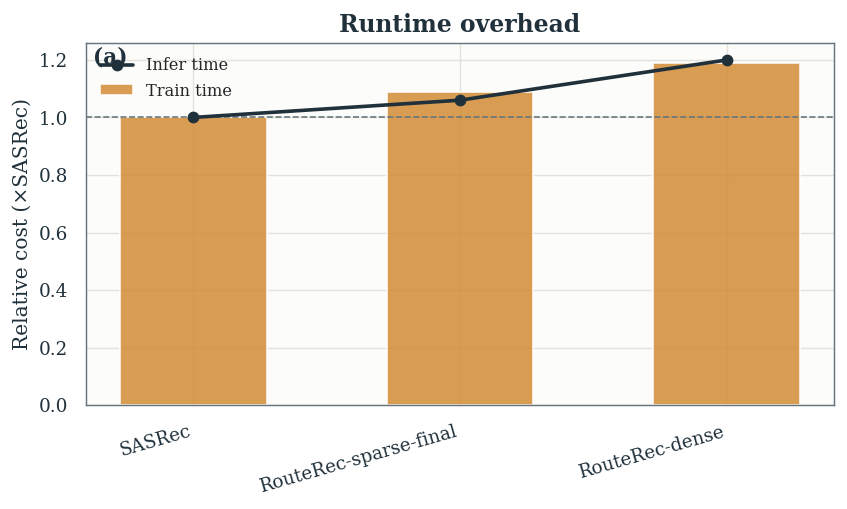

In [ ]:
# [optional / debug] runtime overhead chart — paper uses tab:efficiency-main table, not this figure
fig, ax = plt.subplots(1, 1, figsize=(6.4, 3.8), constrained_layout=True)
x = list(range(len(summary)))
ax.bar(x, summary['train_time_ratio'], width=0.55,
       color=PALETTE['orange'], alpha=0.85, label='Train time', zorder=2)
ax.plot(x, summary['infer_time_ratio'],
        color=PALETTE['ink'], marker='o', linewidth=2.0,
        markersize=5.5, zorder=3, label='Infer time')
ax.set_xticks(x)
ax.set_xticklabels(summary['model_name'], rotation=16, ha='right')
ax.axhline(1.0, color=PALETTE['muted'], linewidth=0.9, linestyle='--')
ax.set_ylabel('Relative cost (×SASRec)')
ax.set_title('Runtime overhead  [debug view]')
ax.legend(loc='upper left', fontsize=9)
panel_label(ax, 'a')
plt.show()


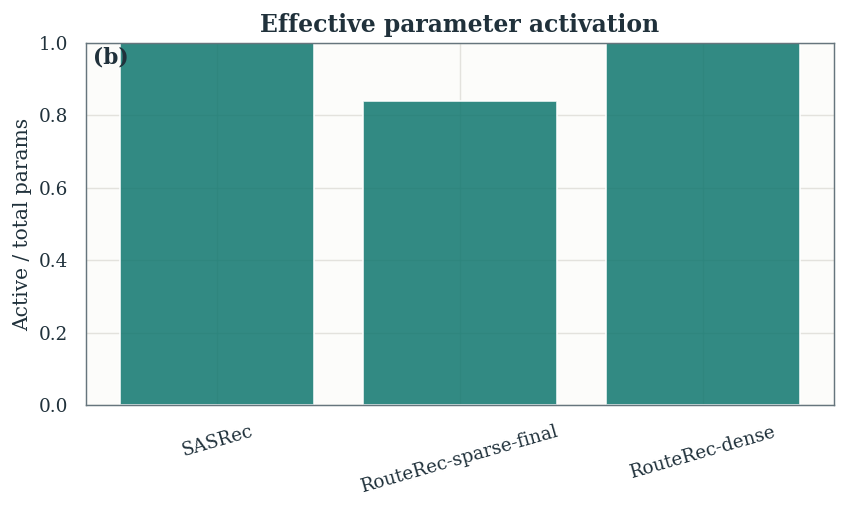

In [ ]:
# [optional / debug] active-parameter ratio chart — paper uses tab:efficiency-main table, not this figure
fig, ax = plt.subplots(1, 1, figsize=(6.4, 3.8), constrained_layout=True)
ax.bar(summary['model_name'], summary['active_ratio'],
       color=PALETTE['route'], alpha=0.85)
ax.set_ylim(0.0, min(1.0, float(summary['active_ratio'].max()) + 0.12))
ax.tick_params(axis='x', rotation=16)
ax.set_ylabel('Active / total params')
ax.set_title('Effective parameter activation  [debug view]')
panel_label(ax, 'b')
plt.show()
